<a href="https://colab.research.google.com/github/Adi4755t/ROADLENS/blob/main/RoadLens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RoadLens India — Indian Road Accident Pattern & Hotspot Analysis

**DVT / Data Visualization Tools Lab Project**

This notebook analyzes the provided Indian road accident dataset using:

- **NumPy** — numerical analysis
- **Pandas** — data loading, cleaning, filtering and aggregation
- **Matplotlib** — static visualizations
- **Seaborn** — statistical/EDA visualizations
- **Plotly** — interactive visualizations and hotspot mapping

> The findings in this notebook describe the provided dataset and should not be interpreted as official national accident statistics.


In [ ]:
# 1. Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from IPython.display import display

sns.set_theme(style="darkgrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load the dataset

In [ ]:


from google.colab import files
uploaded = files.upload()

file_name = next(iter(uploaded))
df = pd.read_csv(file_name)

print(f"Dataset loaded: {file_name}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
display(df.head())


Saving indian_roads_dataset.csv to indian_roads_dataset.csv
Dataset loaded: indian_roads_dataset.csv
Rows: 20,000
Columns: 24


,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,22-10-2023,05:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,21-05-2023,04:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,10-07-2024,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,30-03-2025,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,25-01-2024,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10


## 3. Dataset inspection

In [ ]:

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nDataset information:")
df.info()


Shape: (20000, 24)

Columns:
['accident_id', 'city', 'state', 'latitude', 'longitude', 'date', 'time', 'hour', 'day_of_week', 'is_weekend', 'road_type', 'lanes', 'traffic_signal', 'weather', 'visibility', 'temperature', 'traffic_density', 'cause', 'accident_severity', 'vehicles_involved', 'casualties', 'is_peak_hour', 'festival', 'risk_score']

Data types:


,0
accident_id,int64
city,object
state,object
latitude,float64
longitude,float64
date,object
time,object
hour,int64
day_of_week,object
is_weekend,int64



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   accident_id        20000 non-null  int64  
 1   city               20000 non-null  object 
 2   state              20000 non-null  object 
 3   latitude           20000 non-null  float64
 4   longitude          20000 non-null  float64
 5   date               20000 non-null  object 
 6   time               20000 non-null  object 
 7   hour               20000 non-null  int64  
 8   day_of_week        20000 non-null  object 
 9   is_weekend         20000 non-null  int64  
 10  road_type          20000 non-null  object 
 11  lanes              20000 non-null  int64  
 12  traffic_signal     20000 non-null  int64  
 13  weather            20000 non-null  object 
 14  visibility         20000 non-null  object 
 15  temperature        20000 non-null  int64  
 16  

In [ ]:
#  statistics
display(df.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
accident_id,20000.0,NaN,NaN,NaN,9999.5,5773.647028,0.0,4999.75,9999.5,14999.25,19999.0
city,20000,8,Chandigarh,2577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,20000,7,Maharashtra,5009,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,20000.0,NaN,NaN,NaN,20.389207,6.165791,12.800172,13.198653,18.812008,28.402467,30.79996
longitude,20000.0,NaN,NaN,NaN,78.17333,4.485967,72.700017,73.997979,77.297,80.111089,88.499861
date,20000,1201,03-11-2022,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time,20000,24,02:00,888,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hour,20000.0,NaN,NaN,NaN,11.4872,6.945563,0.0,5.0,12.0,18.0,23.0
day_of_week,20000,7,Monday,2966,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_weekend,20000.0,NaN,NaN,NaN,0.28615,0.451972,0.0,0.0,0.0,1.0,1.0


## 4. Data cleaning and preprocessing

In [ ]:

duplicate_count = df.duplicated().sum()
df = df.drop_duplicates().copy()

print(f"Duplicate rows found: {duplicate_count}")
print(f"Rows after duplicate removal: {len(df):,}")


Duplicate rows found: 0
Rows after duplicate removal: 20,000


In [ ]:
# Missing-value analysis
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "missing_values": missing,
    "missing_percent": missing_pct
})

display(missing_report[missing_report["missing_values"] > 0])

if missing.sum() == 0:
    print("No missing values found.")


,missing_values,missing_percent
festival,19885,99.42


In [ ]:
# Convert numeric columns
numeric_columns = [
    "latitude", "longitude", "hour", "lanes", "visibility",
    "temperature", "traffic_density", "vehicles_involved",
    "casualties", "risk_score"
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Convert date
if "date" in df.columns:
    df["date_parsed"] = pd.to_datetime(
        df["date"],
        dayfirst=True,
        errors="coerce"
    )

# Useful derived columns
if "date_parsed" in df.columns:
    df["year"] = df["date_parsed"].dt.year
    df["month"] = df["date_parsed"].dt.month
    df["month_name"] = df["date_parsed"].dt.strftime("%b")

df["severity_clean"] = df["accident_severity"].astype(str).str.strip().str.lower()

print("Preprocessing complete.")
display(df.head())


Preprocessing complete.


,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,vehicles_involved,casualties,is_peak_hour,festival,risk_score,date_parsed,year,month,month_name,severity_clean
0,0,Pune,Maharashtra,18.680827,73.930388,22-10-2023,05:00,5,Sunday,1,...,2,2,0,NaN,0.85,2023-10-22,2023,10,Oct,fatal
1,1,Mumbai,Maharashtra,18.817732,72.790846,21-05-2023,04:00,4,Sunday,1,...,4,3,0,NaN,0.10,2023-05-21,2023,5,May,major
2,2,Mumbai,Maharashtra,19.096889,72.819424,10-07-2024,13:00,13,Wednesday,0,...,1,1,0,NaN,0.45,2024-07-10,2024,7,Jul,minor
3,3,Chandigarh,Punjab,30.787805,76.847507,30-03-2025,11:00,11,Sunday,1,...,5,2,0,NaN,0.65,2025-03-30,2025,3,Mar,minor
4,4,Chennai,Tamil Nadu,12.965155,80.283313,25-01-2024,16:00,16,Thursday,0,...,2,1,0,NaN,0.10,2024-01-25,2024,1,Jan,minor


## 5. Key project statistics

In [ ]:
total_accidents = len(df)
total_casualties = df["casualties"].sum()
fatal_accidents = (df["severity_clean"] == "fatal").sum()
avg_risk = df["risk_score"].mean()
peak_hour_accidents = (
    df["is_peak_hour"].astype(str).str.strip().isin(["1", "True", "true"]).sum()
)

summary = pd.DataFrame({
    "Metric": [
        "Total accidents",
        "Total casualties",
        "Fatal accidents",
        "Average risk score",
        "Peak-hour accidents"
    ],
    "Value": [
        total_accidents,
        total_casualties,
        fatal_accidents,
        round(avg_risk, 4),
        peak_hour_accidents
    ]
})

display(summary)


,Metric,Value
0,Total accidents,20000.0000
1,Total casualties,34529.0000
2,Fatal accidents,2987.0000
3,Average risk score,0.4376
4,Peak-hour accidents,4948.0000


## 6. Temporal analysis

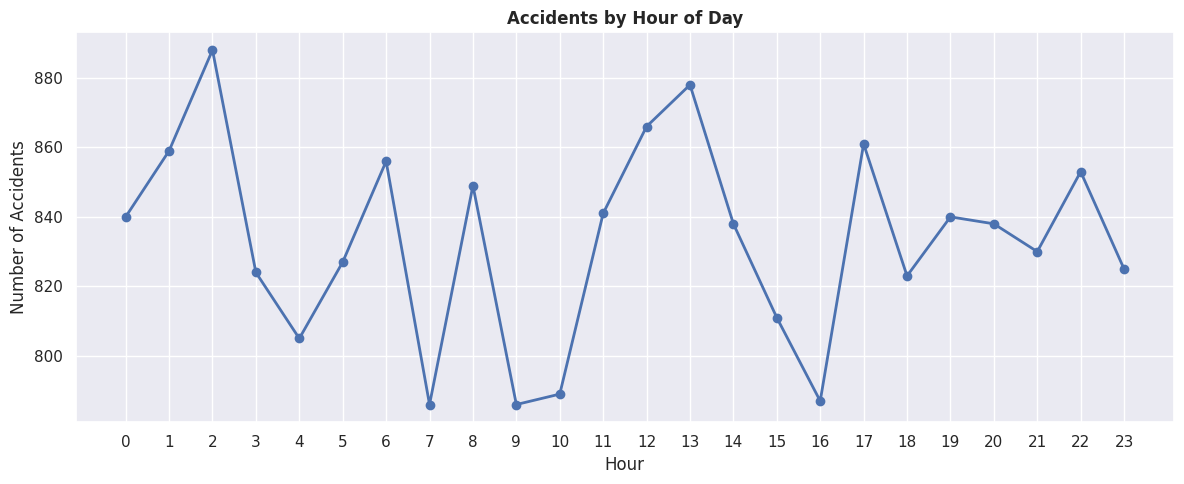

In [ ]:
# Accidents by hour — Matplotlib
hour_counts = df["hour"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(hour_counts.index, hour_counts.values, marker="o", linewidth=2)
plt.title("Accidents by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")
plt.xticks(range(24))
plt.tight_layout()
plt.show()


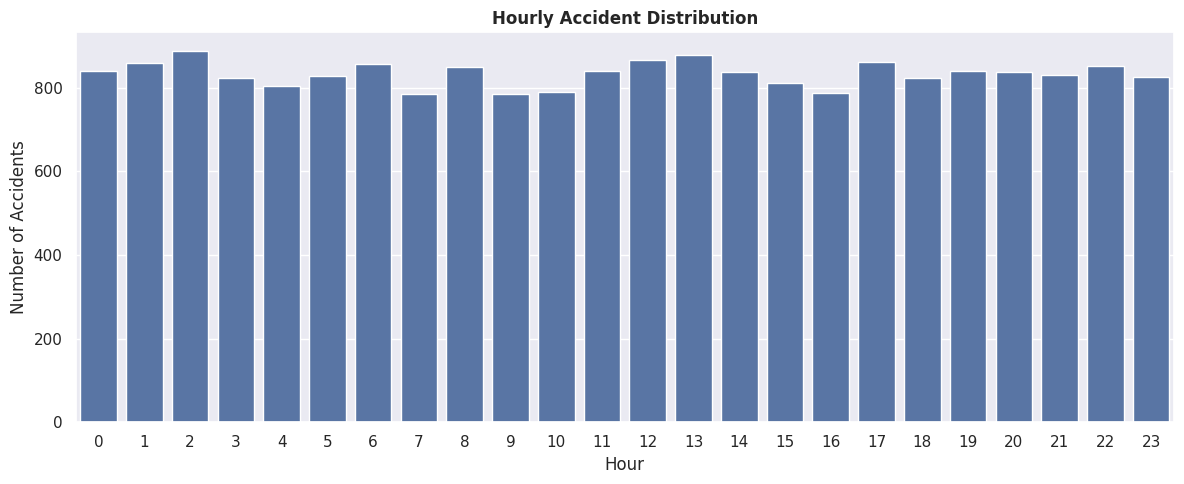

In [ ]:
# Accidents by hour — Seaborn
plt.figure(figsize=(12, 5))
sns.barplot(
    x=hour_counts.index,
    y=hour_counts.values
)
plt.title("Hourly Accident Distribution")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()


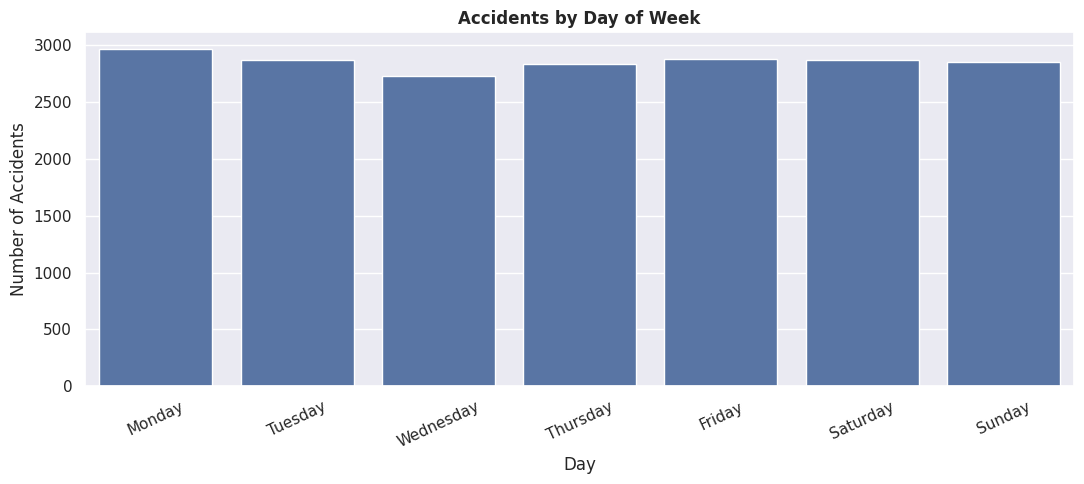

In [ ]:
# Accidents by day of week
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_counts = df["day_of_week"].astype(str).str.title().value_counts()
day_counts = day_counts.reindex(day_order).fillna(0)

plt.figure(figsize=(11, 5))
sns.barplot(x=day_counts.index, y=day_counts.values)
plt.title("Accidents by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


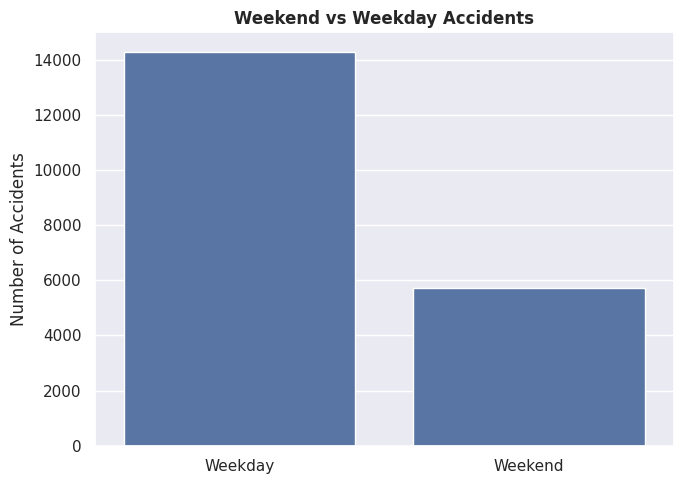

In [ ]:
# Weekend vs weekday
weekend_counts = (
    df["is_weekend"]
    .astype(str)
    .str.lower()
    .map({"1": "Weekend", "true": "Weekend", "0": "Weekday", "false": "Weekday"})
    .value_counts()
)

plt.figure(figsize=(7, 5))
sns.barplot(x=weekend_counts.index, y=weekend_counts.values)
plt.title("Weekend vs Weekday Accidents")
plt.xlabel("")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()


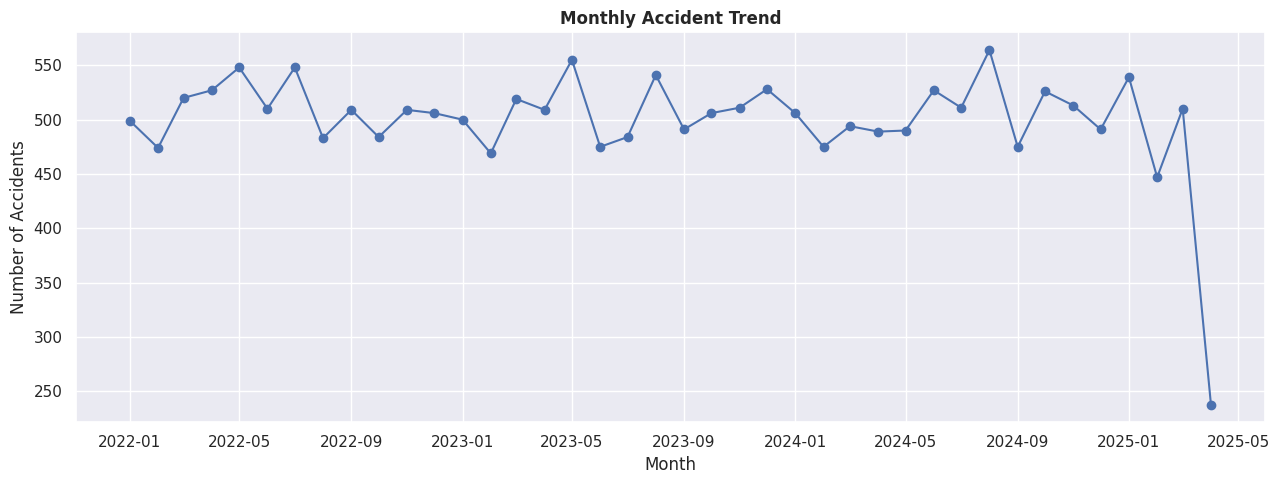

In [ ]:
# Monthly trend
if "date_parsed" in df.columns:
    monthly = (
        df.dropna(subset=["date_parsed"])
          .set_index("date_parsed")
          .resample("MS")
          .size()
    )

    plt.figure(figsize=(13, 5))
    plt.plot(monthly.index, monthly.values, marker="o")
    plt.title("Monthly Accident Trend")
    plt.xlabel("Month")
    plt.ylabel("Number of Accidents")
    plt.tight_layout()
    plt.show()


## 7. Severity analysis

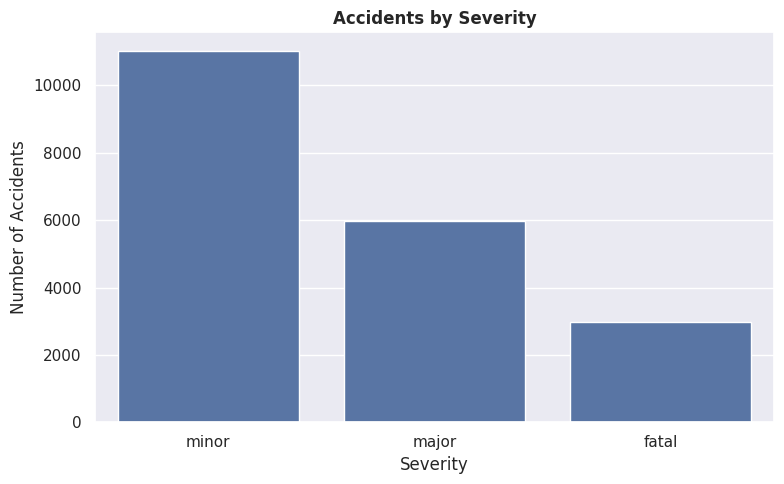

In [ ]:
severity_counts = df["severity_clean"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(
    x=severity_counts.index,
    y=severity_counts.values
)
plt.title("Accidents by Severity")
plt.xlabel("Severity")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()


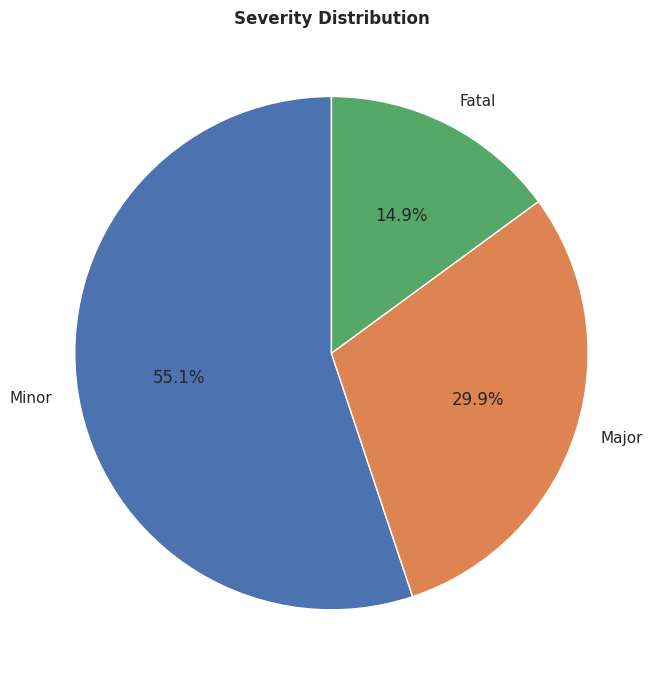

In [ ]:
# Severity proportion
plt.figure(figsize=(7, 7))
plt.pie(
    severity_counts.values,
    labels=severity_counts.index.str.title(),
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Severity Distribution")
plt.tight_layout()
plt.show()


## 8. Cause analysis

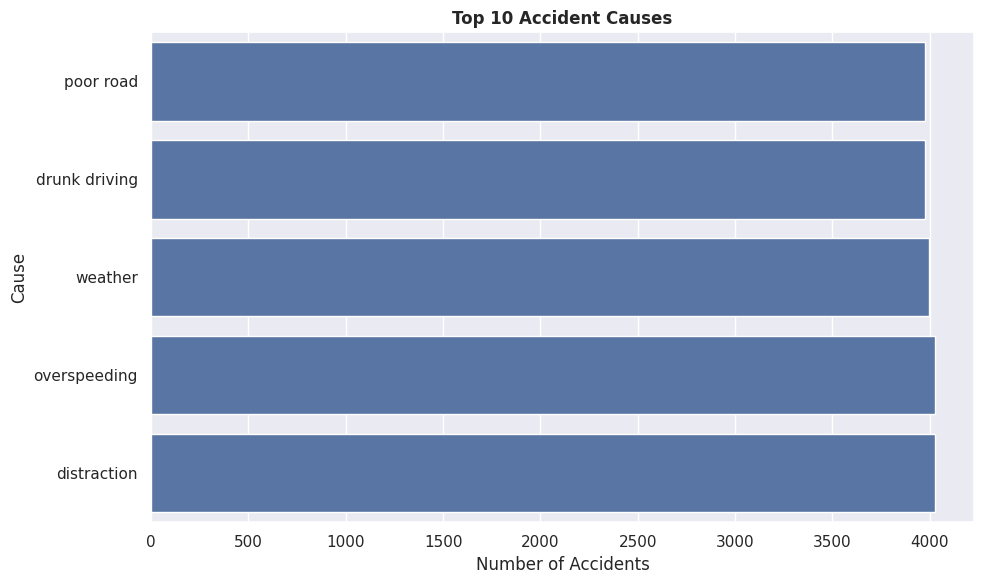

In [ ]:
cause_counts = (
    df["cause"]
    .astype(str)
    .str.strip()
    .value_counts()
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=cause_counts.values,
    y=cause_counts.index
)
plt.title("Top 10 Accident Causes")
plt.xlabel("Number of Accidents")
plt.ylabel("Cause")
plt.tight_layout()
plt.show()


## 9. Weather and environmental analysis

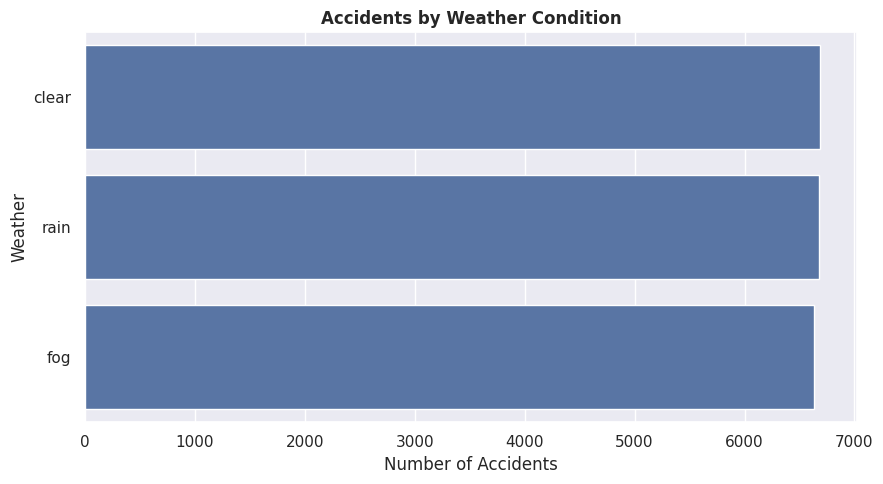

In [ ]:
weather_counts = df["weather"].astype(str).str.strip().value_counts()

plt.figure(figsize=(9, 5))
sns.barplot(x=weather_counts.values, y=weather_counts.index)
plt.title("Accidents by Weather Condition")
plt.xlabel("Number of Accidents")
plt.ylabel("Weather")
plt.tight_layout()
plt.show()


## 11. City and state analysis

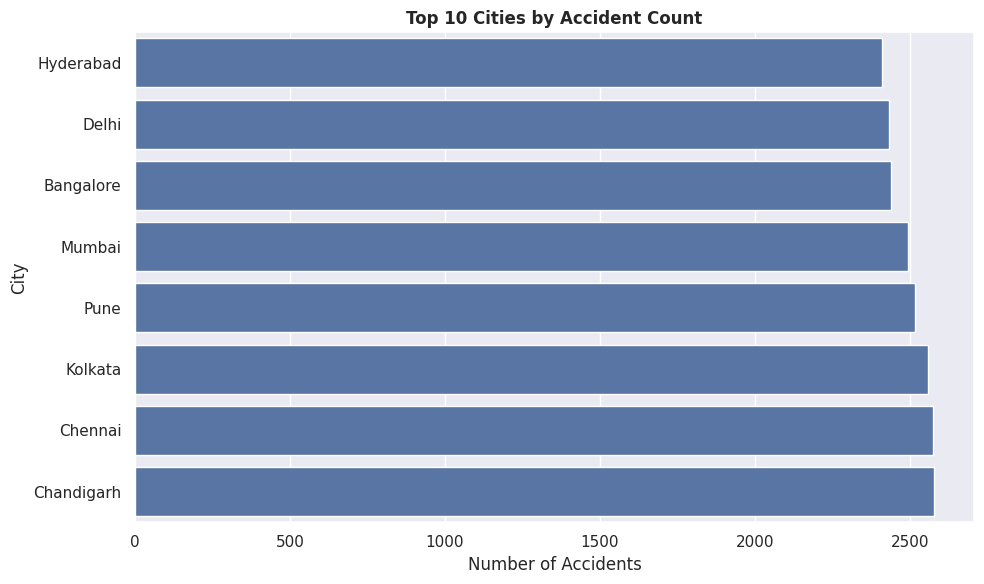

In [ ]:
top_cities = df["city"].astype(str).str.strip().value_counts().head(10).sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=top_cities.values, y=top_cities.index)
plt.title("Top 10 Cities by Accident Count")
plt.xlabel("Number of Accidents")
plt.ylabel("City")
plt.tight_layout()
plt.show()


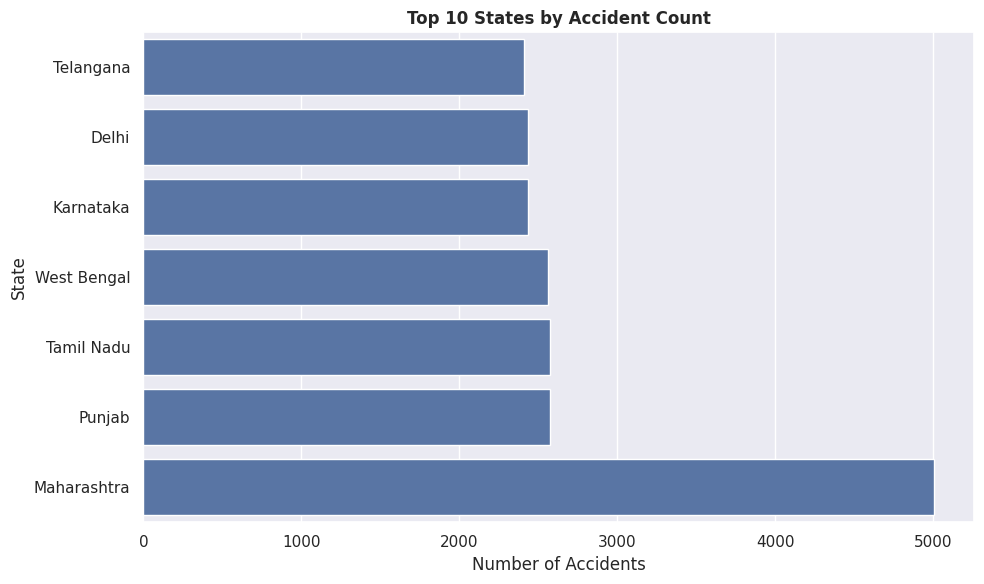

In [ ]:
top_states = df["state"].astype(str).str.strip().value_counts().head(10).sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=top_states.values, y=top_states.index)
plt.title("Top 10 States by Accident Count")
plt.xlabel("Number of Accidents")
plt.ylabel("State")
plt.tight_layout()
plt.show()


## 12. Risk-score analysis

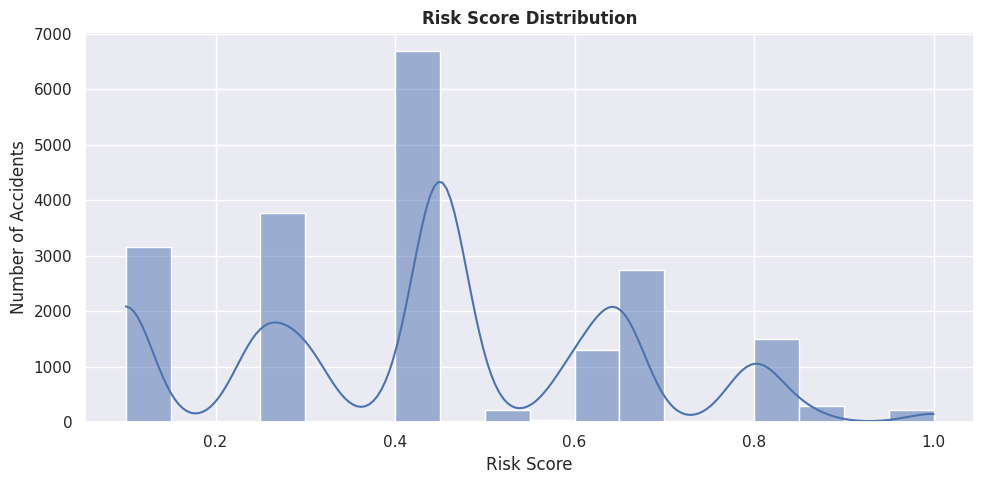

count    20000.000000
mean         0.437585
std          0.218130
min          0.100000
25%          0.250000
50%          0.450000
75%          0.600000
max          1.000000
Name: risk_score, dtype: float64


In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(
    df["risk_score"].dropna(),
    bins=18,
    kde=True
)
plt.title("Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()

print(df["risk_score"].describe())


In [ ]:
# Interactive severity distribution
plot_severity = severity_counts.reset_index()
plot_severity.columns = ["Severity", "Accidents"]

fig = px.pie(
    plot_severity,
    names="Severity",
    values="Accidents",
    title="Interactive Severity Distribution"
)
fig.update_layout(template="plotly_dark")
fig.show()


In [ ]:
# Interactive top cities
plot_city = (
    df["city"]
    .astype(str)
    .str.strip()
    .value_counts()
    .head(10)
    .reset_index()
)
plot_city.columns = ["City", "Accidents"]

fig = px.bar(
    plot_city.sort_values("Accidents"),
    x="Accidents",
    y="City",
    orientation="h",
    title="Interactive Top 10 Accident Cities"
)
fig.update_layout(template="plotly_dark")
fig.show()


## 15. Geographic hotspot visualization

In [ ]:
# Interactive accident hotspot map
map_df = df.dropna(subset=["latitude", "longitude"]).copy()

fig = px.scatter_mapbox(
    map_df,
    lat="latitude",
    lon="longitude",
    color="risk_score",
    size="casualties",
    hover_name="city",
    hover_data=[
        "state",
        "accident_severity",
        "cause",
        "weather",
        "risk_score"
    ],
    color_continuous_scale="Turbo",
    zoom=4,
    height=650,
    title="Indian Road Accident Hotspots"
)

fig.update_layout(
    mapbox_style="open-street-map",
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.show()


## 16. City risk analysis

In [ ]:
city_risk = (
    df.groupby("city", as_index=False)
      .agg(
          accidents=("accident_id", "count"),
          avg_risk=("risk_score", "mean"),
          casualties=("casualties", "sum")
      )
      .sort_values("accidents", ascending=False)
      .head(15)
)

display(city_risk)

fig = px.bar(
    city_risk.sort_values("avg_risk"),
    x="avg_risk",
    y="city",
    orientation="h",
    color="avg_risk",
    color_continuous_scale="Turbo",
    title="Average Risk Score by High-Accident Cities",
    hover_data=["accidents", "casualties"]
)

fig.update_layout(template="plotly_dark")
fig.show()


,city,accidents,avg_risk,casualties
1,Chandigarh,2577,0.441618,4377
2,Chennai,2575,0.437573,4567
5,Kolkata,2559,0.434584,4508
7,Pune,2517,0.435836,4419
6,Mumbai,2492,0.434350,4297
0,Bangalore,2438,0.440217,4128
3,Delhi,2433,0.437115,4175
4,Hyderabad,2409,0.439456,4058
